In [37]:
# Downloading the IMDB Dataset
!curl -O https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
!tar -xf aclImdb_v1.tar.gz
!rm -r aclImdb/train/unsup

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 80.2M  100 80.2M    0     0  3814k      0  0:00:21  0:00:21 --:--:-- 4336k


In [105]:
import os, pathlib, shutil, random
from tensorflow import keras
batch_size = 32
base_dir = pathlib.Path("/content/aclImdb")
valid_dir = base_dir / "val"
train_dir = base_dir / "train"
for category in ("neg", "pos"):
    os.makedirs(valid_dir / category, exist_ok=True )

    files = os.listdir(tr_dir7 / category)
    random.Random(1496).shuffle(files)
    num_val_samples = 10000
    v_files = files[-num_val_samples:]
    for fname in v_files:
        shutil.move(train_dir / category / fname,
                    valid_dir / category / fname)

tr_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/train", batch_size= batch_size
).take(100)  # Restrict training samples to 100

v_ds = keras.utils.text_dataset_from_directory(
    "/content/aclImdb/val", batch_size= batch_size
)
te_ds = keras.utils.text_dataset_from_directory(
    "aclImdb/test", batch_size= batch_size
)
te_only_tr_ds = tr_ds.map(lambda x, y: x)

Found 5000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


**A sequence model built on one-hot encoded vector sequences**

In [38]:
from tensorflow.keras import layers

max_length = 150   # Cutoff reviews after 150 words
train_sample = 10000 # Consider only the top 10,000 word
t_vectorization = layers.TextVectorization(
    max_tokens= train_sample,
    output_mode="int",
    output_sequence_length= max_length,
)
t_vectorization.adapt(te_only_tr_ds)

int_tr_ds = tr_ds.map(
    lambda x, y: (t_vectorization(x), y),
    num_parallel_calls=4)
int_v_ds = v_ds.map(
    lambda x, y: (t_vectorization(x), y),
    num_parallel_calls=4)
int_te_ds = te_ds.map(
    lambda x, y: (t_vectorization(x), y),
    num_parallel_calls=4)



**Model: "functional"**


In [48]:
import tensorflow as tf  # Model with embedding layer
input = keras.Input(shape=(None,), dtype="int64")
embd = layers.Embedding(input_dim= train_sample, output_dim=256, mask_zero=True)(input)
x = layers.Bidirectional(layers.LSTM(32))(em)
x = layers.Dropout(0.5)(x)
ou = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(input, ou)
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "functional_39"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_37      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_38        │ (None, None, 256) │  2,560,000 │ input_layer_37[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_34        │ (None, None)      │          0 │ input_layer_37[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_39    │ (None, 64)        │     73,984 │ embedding_38[0][… │
│ (Bidirectional)     │                   │            │ not_equal_34[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_39          │ (None, 64)        │          0 │ bidirectional_39… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_39      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_39 (Dense)    │ (None, 1)         │         65 │ dropout_39[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,634,049 (10.05 MB)

 Trainable params: 2,634,049 (10.05 MB)

 Non-trainable params: 0 (0.00 B)

**Developing a fundamental sequencing concept initially**

In [40]:
callback1 = [
    keras.callbacks.ModelCheckpoint("one_hot_bidir_lstm.keras",
                                    save_best_only=True)
]
hist= model.fit(int_tr_ds, validation_data=int_v_ds, epochs=15, callbacks=callback1)
model = keras.models.load_model("one_hot_bidir_lstm.keras")


Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 126ms/step - accuracy: 0.5392 - loss: 0.6879 - val_accuracy: 0.6714 - val_loss: 0.6050
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.7034 - loss: 0.5750 - val_accuracy: 0.7683 - val_loss: 0.5008
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.8397 - loss: 0.3889 - val_accuracy: 0.7716 - val_loss: 0.4778
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.8683 - loss: 0.3182 - val_accuracy: 0.6621 - val_loss: 0.7081
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.9118 - loss: 0.2337 - val_accuracy: 0.7994 - val_loss: 0.4672
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.9497 - loss: 0.1415 - val_accuracy: 0.8007 - val_loss: 0.4600
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.9673 - loss: 0.1043 - val_accuracy: 0.7920 - val_loss: 0.5090
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.9744 - loss: 0.0855 - val_ac

In [43]:
test_loss, test_acc = model.evaluate(int_te_ds)
print(f"Test Loss: {test_loss:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

# Evaluate model on the validation dataset
val_loss, val_acc = model.evaluate(int_v_ds)
print(f"Validation Loss: {val_loss:.3f}")
print(f"Validation Accuracy: {val_acc:.3f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7936 - loss: 0.4561
Test Loss: 0.463
Test Accuracy: 0.792
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7950 - loss: 0.4721
Validation Loss: 0.460
Validation Accuracy: 0.801


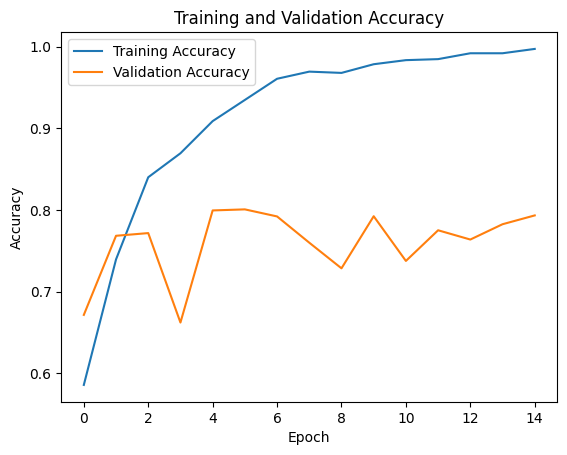

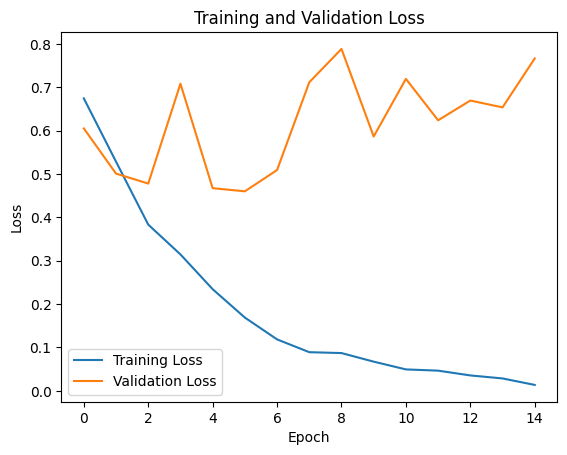

In [44]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.plot(hist.history['accuracy'], label='Training Accuracy')
plt.plot(hist.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(hist.history['loss'], label='Training Loss')
plt.plot(hist.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


## Using the Embedded level to acquire embedded words

**Putting an Anchoring level into Action**



In [46]:
embd_layer = layers.Embedding(input_dim=train_sample, output_dim=256)


Anchor layer system which was developed form Scratch



In [49]:

input1 = keras.Input(shape=(None,), dtype="int64")
embd1 = layers.Embedding(input_dim=train_sample, output_dim=256)(input1)
x = layers.Bidirectional(layers.LSTM(32))(embd1)
x = layers.Dropout(0.5)(x)
out1 = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(input1, out1)
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "functional_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_40 (InputLayer)     │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_43 (Embedding)        │ (None, None, 256)      │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_40                │ (None, 64)             │        73,984 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,634,049 (10.05 MB)

 Trainable params: 2,634,049 (10.05 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
cb1 = [
    keras.callbacks.ModelCheckpoint("embeddings_bidir_gru.keras",
                                    save_best_only=True)
]
hist1= model.fit(int_tr_ds, validation_data=int_v_ds, epochs=15, callbacks=cb1)
embd_model = keras.models.load_model("embeddings_bidir_gru.keras")
print(f"Test acc: {model.evaluate(int_te_ds)[1]:.3f}")

Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.5194 - loss: 0.6927 - val_accuracy: 0.5791 - val_loss: 0.6697
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - accuracy: 0.6768 - loss: 0.6194 - val_accuracy: 0.5918 - val_loss: 0.7241
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.7767 - loss: 0.5005 - val_accuracy: 0.7523 - val_loss: 0.5177
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.8402 - loss: 0.3986 - val_accuracy: 0.7536 - val_loss: 0.5123
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - accuracy: 0.8615 - loss: 0.3526 - val_accuracy: 0.7243 - val_loss: 0.6311
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9213 - loss: 0.2445 - val_accuracy: 0.7652 - val_loss: 0.5145
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step - accuracy: 0.9435 - loss: 0.1999 - val_accuracy: 0.7742 - val_loss: 0.5212
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.9439 - loss: 0.1735 - val

In [51]:
test_loss, test_acc = embd_model.evaluate(int_te_ds)
print(f"Test Loss: {test_loss:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

# Evaluate model on the validation dataset
val_loss, val_acc = embd_model.evaluate(int_v_ds)
print(f"Validation Loss: {val_loss:.3f}")
print(f"Validation Accuracy: {val_acc:.3f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7505 - loss: 0.5180
Test Loss: 0.522
Test Accuracy: 0.747
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7508 - loss: 0.5182
Validation Loss: 0.512
Validation Accuracy: 0.754


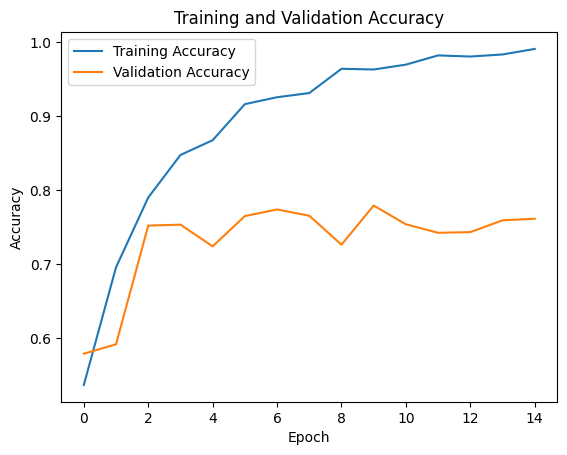

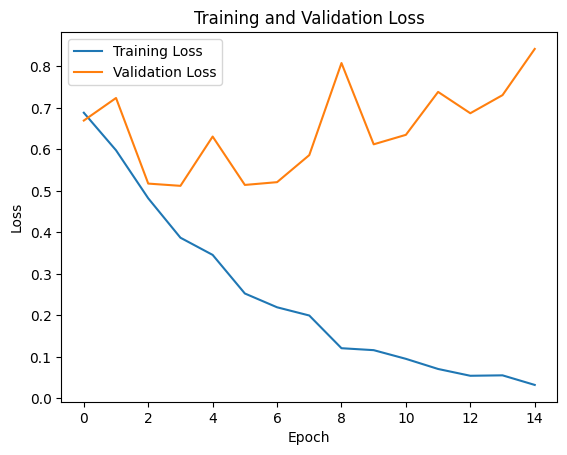

In [52]:
# Plot training and validation accuracy
plt.plot(hist1.history['accuracy'], label='Training Accuracy')
plt.plot(hist1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(hist1.history['loss'], label='Training Loss')
plt.plot(hist1.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

 Recognizing blurring and filling

Applying filtering to an Anchoring level



In [53]:
input2 = keras.Input(shape=(None,), dtype="int64")
embd2 = layers.Embedding(
    input_dim=max_t, output_dim=256, mask_zero=True)(input2)
x = layers.Bidirectional(layers.LSTM(32))(embd2)
x = layers.Dropout(0.5)(x)
out2 = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(input2, out2)
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()

Model: "functional_41"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_41      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_44        │ (None, None, 256) │  2,560,000 │ input_layer_41[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_37        │ (None, None)      │          0 │ input_layer_41[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_41    │ (None, 64)        │     73,984 │ embedding_44[0][… │
│ (Bidirectional)     │                   │            │ not_equal_37[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_41          │ (None, 64)        │          0 │ bidirectional_41… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 1)         │         65 │ dropout_41[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,634,049 (10.05 MB)

 Trainable params: 2,634,049 (10.05 MB)

 Non-trainable params: 0 (0.00 B)

In [54]:
callback2 = [
    keras.callbacks.ModelCheckpoint("embeddings_bidir_gru_with_masking.keras",
                                    save_best_only=True)
]
hist2=model.fit(int_tr_ds, validation_data=int_v_ds, epochs=15, callbacks=callback2)
embd2_model = keras.models.load_model("embeddings_bidir_gru_with_masking.keras")
print(f"Test acc: {embd2_model.evaluate(int_te_ds)[1]:.3f}")


Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.5220 - loss: 0.6904 - val_accuracy: 0.6694 - val_loss: 0.6211
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.6971 - loss: 0.5728 - val_accuracy: 0.6705 - val_loss: 0.6094
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accuracy: 0.8143 - loss: 0.4230 - val_accuracy: 0.7911 - val_loss: 0.4540
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.8636 - loss: 0.3342 - val_accuracy: 0.7602 - val_loss: 0.5832
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.9052 - loss: 0.2398 - val_accuracy: 0.8013 - val_loss: 0.4653
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - accuracy: 0.9486 - loss: 0.1433 - val_accuracy: 0.7024 - val_loss: 0.6810
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.9514 - loss: 0.1332 - val_accuracy: 0.7814 - val_loss: 0.5003
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.9697 - loss: 0.0988 - val

In [56]:
test_loss, test_acc = embd2_model.evaluate(int_te_ds)
print(f"Test Loss: {test_loss:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

# Evaluate model on the validation dataset
val_loss, val_acc = embd2_model.evaluate(int_v_ds)
print(f"Validation Loss: {val_loss:.3f}")
print(f"Validation Accuracy: {val_acc:.3f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7933 - loss: 0.4489
Test Loss: 0.453
Test Accuracy: 0.792
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7848 - loss: 0.4593
Validation Loss: 0.454
Validation Accuracy: 0.791


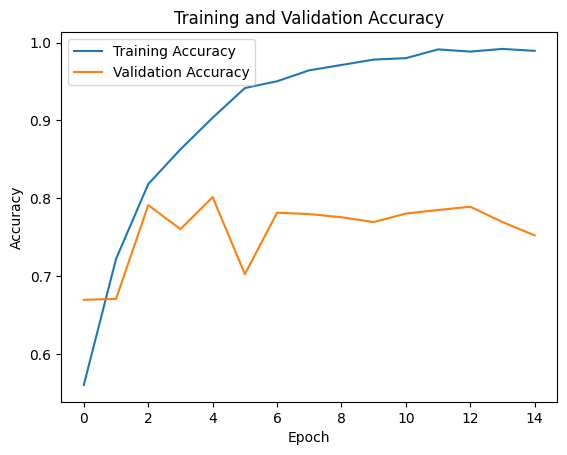

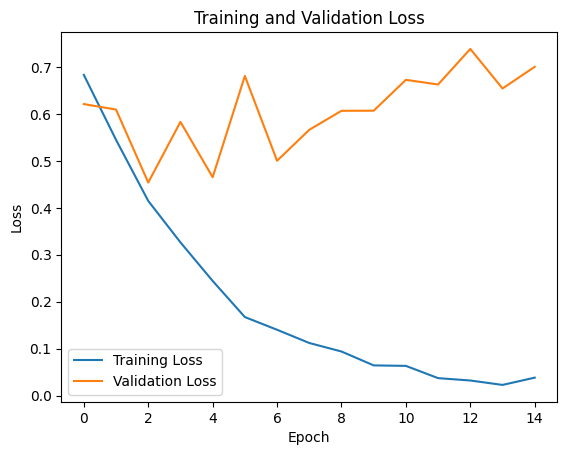

In [57]:
# Plot training and validation accuracy
plt.plot(hist2.history['accuracy'], label='Training Accuracy')
plt.plot(hist2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(hist2.history['loss'], label='Training Loss')
plt.plot(hist2.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Preconditioned word embeds are used


In [58]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

--2025-11-13 01:45:34--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-11-13 01:45:34--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-11-13 01:45:35--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.1’

gl

Interpreting the word-embeddings package for One



In [106]:
import numpy as np
path_glove_file = "glove.6B.100d.txt"

embd_index = {}
with open(path_glove_file) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embd_index[word] = coefs

print(f"Found {len(embd_index)} word vectors.")

Found 400000 word vectors.


Setting up the matrix for the GloVe website embedded words



In [107]:
embd_dim = 100

vocab = t_vectorization.get_vocabulary()
wo_index = dict(zip(vocab, range(len(vocab))))

embd_matrix = np.zeros((train_sample, embd_dim))
for word, i in wo_index.items():
    if i < train_sample:
        embd_vector = embd_index.get(word)
    if embd_vector is not None:
        embd_matrix[i] = embd_vector

In [108]:
embd_layer = layers.Embedding(
    train_sample,
    embd_dim,
    embeddings_initializer=keras.initializers.Constant(embd_matrix),
    trainable=False,
    mask_zero=True,
)

### Architecture with an embedded level which has been trained


In [116]:
input4 = keras.Input(shape=(None,), dtype="int64")
embd4 = embd_layer(input4)
x = layers.Bidirectional(layers.LSTM(32))(embd4)
x = layers.Dropout(0.5)(x)
out4 = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(input4, out4)
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])
model.summary()


Model: "functional_90"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_91      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_83        │ (None, None, 100) │  1,000,000 │ input_layer_91[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_79        │ (None, None)      │          0 │ input_layer_91[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_91    │ (None, 64)        │     34,048 │ embedding_83[3][… │
│ (Bidirectional)     │                   │            │ not_equal_79[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_91          │ (None, 64)        │          0 │ bidirectional_91… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_91 (Dense)    │ (None, 1)         │         65 │ dropout_91[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,034,113 (3.94 MB)

 Trainable params: 34,113 (133.25 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

In [117]:

callback4 = [
    keras.callbacks.ModelCheckpoint("glove_embeddings_sequence_model.keras",
                                    save_best_only=True)
]
hist4 = model.fit(int_tr_ds, validation_data=int_v_ds, epochs=15, callbacks=callback4)
model = keras.models.load_model("glove_embeddings_sequence_model.keras")
print(f"Test acc: {model.evaluate(int_te_ds)[1]:.3f}")

Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 103ms/step - accuracy: 0.5149 - loss: 0.7053 - val_accuracy: 0.6101 - val_loss: 0.6627
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - accuracy: 0.6239 - loss: 0.6545 - val_accuracy: 0.6738 - val_loss: 0.6140
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.6768 - loss: 0.6023 - val_accuracy: 0.6524 - val_loss: 0.6416
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.7164 - loss: 0.5551 - val_accuracy: 0.7168 - val_loss: 0.5553
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - accuracy: 0.7515 - loss: 0.5199 - val_accuracy: 0.7110 - val_loss: 0.5616
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.7299 - loss: 0.5223 - val_accuracy: 0.7368 - val_loss: 0.5277
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.7685 - loss: 0.4851 - val_accuracy: 0.7599 - val_loss: 0.5000
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.7929 - loss: 0.459

In [119]:

test_loss, test_acc = model.evaluate(int_te_ds)
print(f"Test Loss: {test_loss:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

# Evaluate model on the validation dataset
val_loss, val_acc = model.evaluate(int_v_ds)
print(f"Validation Loss: {val_loss:.3f}")
print(f"Validation Accuracy: {val_acc:.3f}")


782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7922 - loss: 0.4434
Test Loss: 0.449
Test Accuracy: 0.787
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7845 - loss: 0.4564
Validation Loss: 0.454
Validation Accuracy: 0.784


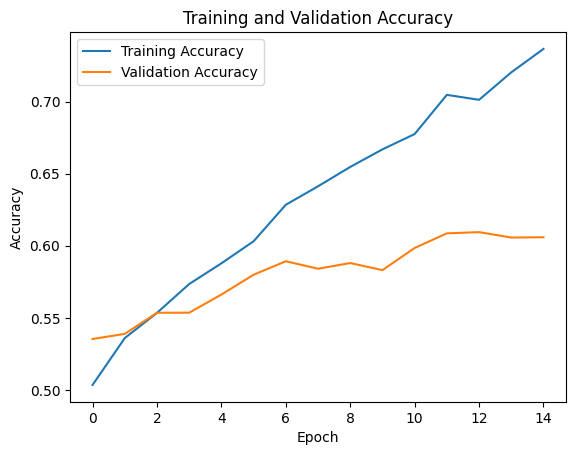

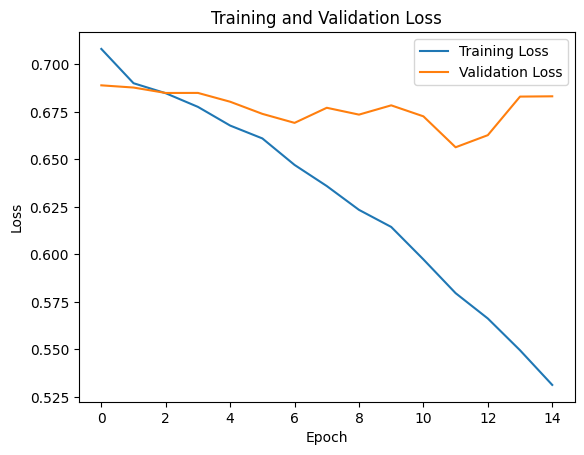

In [120]:
# Plot training and validation accuracy
plt.plot(hist3.history['accuracy'], label='Training Accuracy')
plt.plot(hist3.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss
plt.plot(hist3.history['loss'], label='Training Loss')
plt.plot(hist3.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Training with 100 samples...
Found 5000 files belonging to 2 classes.
Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.5081 - loss: 0.6937 - val_accuracy: 0.5349 - val_loss: 0.7335
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - accuracy: 0.6435 - loss: 0.6349 - val_accuracy: 0.7199 - val_loss: 0.5654
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.7825 - loss: 0.4922 - val_accuracy: 0.7900 - val_loss: 0.4686
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.8692 - loss: 0.3472 - val_accuracy: 0.7901 - val_loss: 0.4569
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.9062 - loss: 0.2774 - val_accuracy: 0.6834 - val_loss: 0.8955
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step - accuracy: 0.9232 - loss: 0.2324 - val_accuracy: 0.6988 - val_loss: 0.5998
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.9318 - loss: 0.2001 - val_accuracy: 0.8048 - val_loss: 0.4934
Epoch 8/10
100/100 ━━━━━

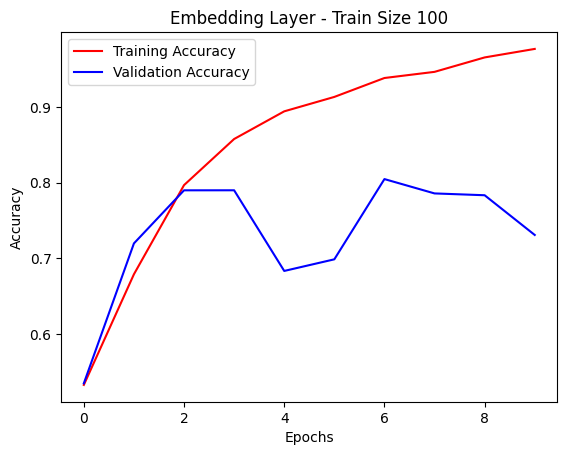

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - accuracy: 0.5259 - loss: 0.6980 - val_accuracy: 0.6067 - val_loss: 0.6652
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.6205 - loss: 0.6545 - val_accuracy: 0.6774 - val_loss: 0.6073
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.6650 - loss: 0.6134 - val_accuracy: 0.7223 - val_loss: 0.5638
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.7016 - loss: 0.5725 - val_accuracy: 0.7256 - val_loss: 0.5512
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.7465 - loss: 0.5326 - val_accuracy: 0.7516 - val_loss: 0.5164
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - accuracy: 0.7663 - loss: 0.5081 - val_accuracy: 0.7456 - val_loss: 0.5138
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.7752 - loss: 0.5010 - val_accuracy: 0.7465 - val_loss: 0.5081
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.7782 - loss: 0.4758 - val_acc

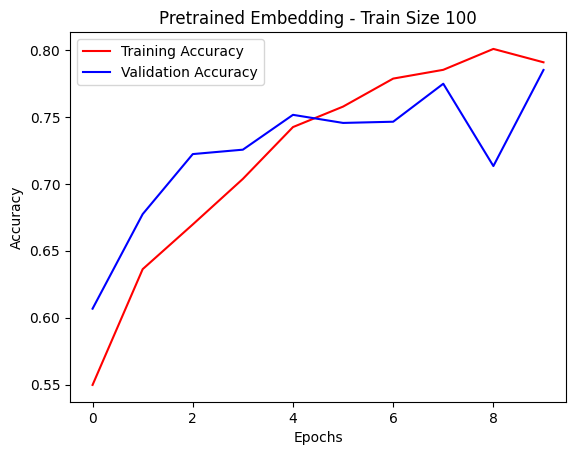

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7816 - loss: 0.4618
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7926 - loss: 0.4565
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7782 - loss: 0.4672
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7878 - loss: 0.4587
{'train_size': 100, 'model': 'Embedding Layer', 'train_acc': 0.9768750071525574, 'val_acc': 0.7900500297546387, 'test_acc': 0.7787600159645081, 'train_loss': 0.06957553327083588, 'val_loss': 0.45687827467918396, 'test_loss': 0.46595320105552673}
{'train_size': 100, 'model': 'Pretrained Embedding', 'train_acc': 0.7909374833106995, 'val_acc': 0.7851999998092651, 'test_acc': 0.7805600166320801, 'train_loss': 0.44628044962882996, 'val_loss': 0.4581722021102905, 'test_loss': 0.46631598472595215}
Training with 1000 samples...
Found 5000 files belonging to 2 classes.
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.5121 - loss: 0.6921 - val_accuracy: 0.6132 - val_loss: 0.6633
E

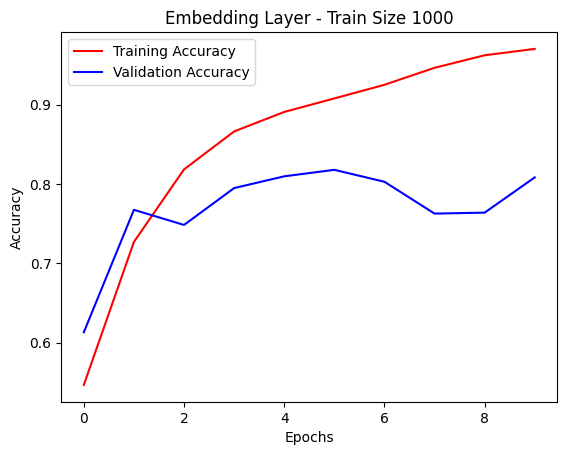

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.5278 - loss: 0.6987 - val_accuracy: 0.6656 - val_loss: 0.6202
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 86ms/step - accuracy: 0.6745 - loss: 0.6143 - val_accuracy: 0.6679 - val_loss: 0.6115
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.7131 - loss: 0.5682 - val_accuracy: 0.7253 - val_loss: 0.5535
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.7101 - loss: 0.5677 - val_accuracy: 0.7365 - val_loss: 0.5316
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 83ms/step - accuracy: 0.7449 - loss: 0.5157 - val_accuracy: 0.7685 - val_loss: 0.4895
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.7670 - loss: 0.4900 - val_accuracy: 0.7104 - val_loss: 0.5797
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.7962 - loss: 0.4589 - val_accuracy: 0.7339 - val_loss: 0.5640
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.8033 - loss: 0.4471 - val_

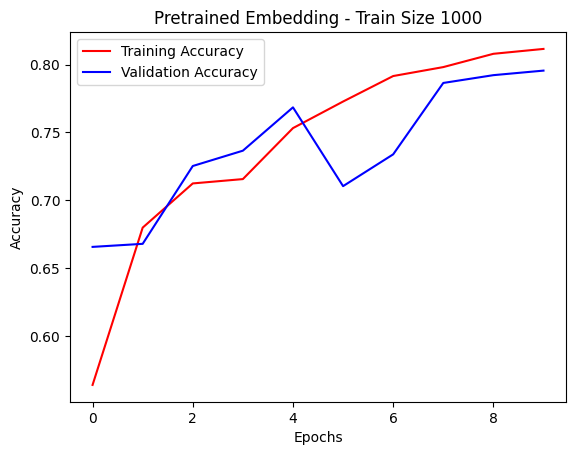

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8033 - loss: 0.4327
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8094 - loss: 0.4263
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7935 - loss: 0.4396
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7968 - loss: 0.4389
{'train_size': 100, 'model': 'Embedding Layer', 'train_acc': 0.9768750071525574, 'val_acc': 0.7900500297546387, 'test_acc': 0.7787600159645081, 'train_loss': 0.06957553327083588, 'val_loss': 0.45687827467918396, 'test_loss': 0.46595320105552673}
{'train_size': 100, 'model': 'Pretrained Embedding', 'train_acc': 0.7909374833106995, 'val_acc': 0.7851999998092651, 'test_acc': 0.7805600166320801, 'train_loss': 0.44628044962882996, 'val_loss': 0.4581722021102905, 'test_loss': 0.46631598472595215}
{'train_size': 1000, 'model': 'Embedding Layer', 'train_acc': 0.9702000021934509, 'val_acc': 0.8096500039100647, 'test_acc': 0.7981600165367126, 'train_loss': 0.10288064926862717, 'val_loss': 0.4262983

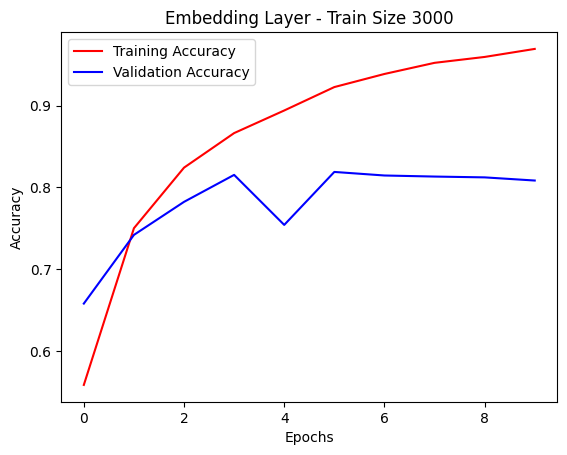

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - accuracy: 0.5419 - loss: 0.6985 - val_accuracy: 0.6345 - val_loss: 0.6422
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.6612 - loss: 0.6328 - val_accuracy: 0.7240 - val_loss: 0.5747
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.7072 - loss: 0.5895 - val_accuracy: 0.5870 - val_loss: 0.7156
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step - accuracy: 0.7229 - loss: 0.5642 - val_accuracy: 0.7374 - val_loss: 0.5722
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.7475 - loss: 0.5294 - val_accuracy: 0.7620 - val_loss: 0.5047
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.7703 - loss: 0.4943 - val_accuracy: 0.7710 - val_loss: 0.4836
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.7814 - loss: 0.4683 - val_accuracy: 0.7771 - val_loss: 0.4729
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.7963 - loss: 0.4483 - val_ac

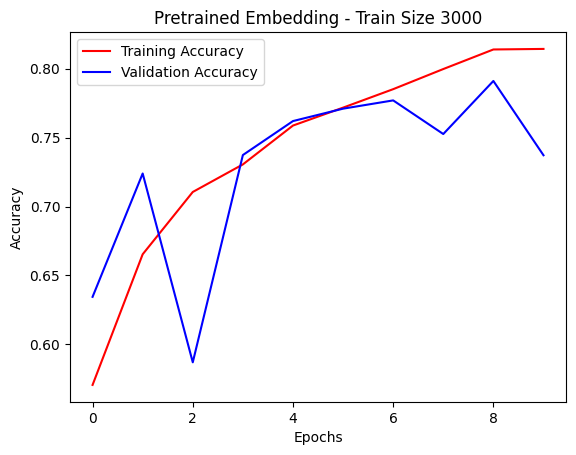

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8095 - loss: 0.4888
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8149 - loss: 0.4750
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7856 - loss: 0.4580
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7913 - loss: 0.4552
{'train_size': 100, 'model': 'Embedding Layer', 'train_acc': 0.9768750071525574, 'val_acc': 0.7900500297546387, 'test_acc': 0.7787600159645081, 'train_loss': 0.06957553327083588, 'val_loss': 0.45687827467918396, 'test_loss': 0.46595320105552673}
{'train_size': 100, 'model': 'Pretrained Embedding', 'train_acc': 0.7909374833106995, 'val_acc': 0.7851999998092651, 'test_acc': 0.7805600166320801, 'train_loss': 0.44628044962882996, 'val_loss': 0.4581722021102905, 'test_loss': 0.46631598472595215}
{'train_size': 1000, 'model': 'Embedding Layer', 'train_acc': 0.9702000021934509, 'val_acc': 0.8096500039100647, 'test_acc': 0.7981600165367126, 'train_loss': 0.10288064926862717, 'val_loss': 0.426298

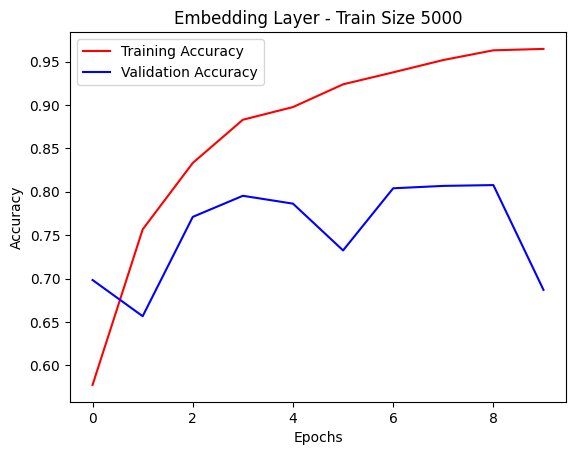

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - accuracy: 0.5562 - loss: 0.6925 - val_accuracy: 0.6261 - val_loss: 0.6507
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.6505 - loss: 0.6402 - val_accuracy: 0.6745 - val_loss: 0.6183
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.7006 - loss: 0.5907 - val_accuracy: 0.7372 - val_loss: 0.5429
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.7443 - loss: 0.5343 - val_accuracy: 0.6999 - val_loss: 0.5727
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.7613 - loss: 0.5037 - val_accuracy: 0.6550 - val_loss: 0.6644
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.7705 - loss: 0.4861 - val_accuracy: 0.7758 - val_loss: 0.4810
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.7882 - loss: 0.4703 - val_accuracy: 0.7564 - val_loss: 0.5018
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.7980 - loss: 0.4441 - val_a

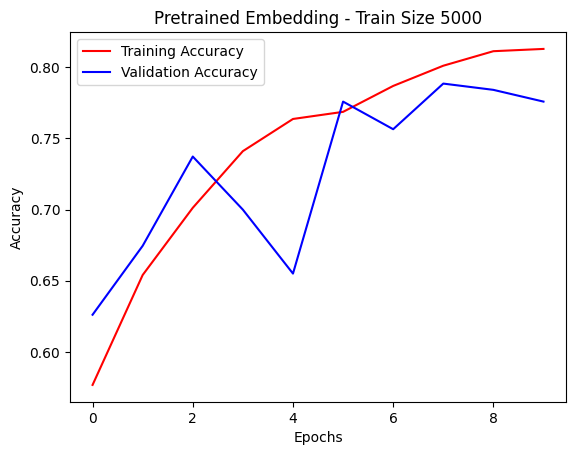

782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7924 - loss: 0.4698
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7955 - loss: 0.4600
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7831 - loss: 0.4581
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7883 - loss: 0.4562
{'train_size': 100, 'model': 'Embedding Layer', 'train_acc': 0.9768750071525574, 'val_acc': 0.7900500297546387, 'test_acc': 0.7787600159645081, 'train_loss': 0.06957553327083588, 'val_loss': 0.45687827467918396, 'test_loss': 0.46595320105552673}
{'train_size': 100, 'model': 'Pretrained Embedding', 'train_acc': 0.7909374833106995, 'val_acc': 0.7851999998092651, 'test_acc': 0.7805600166320801, 'train_loss': 0.44628044962882996, 'val_loss': 0.4581722021102905, 'test_loss': 0.46631598472595215}
{'train_size': 1000, 'model': 'Embedding Layer', 'train_acc': 0.9702000021934509, 'val_acc': 0.8096500039100647, 'test_acc': 0.7981600165367126, 'train_loss': 0.10288064926862717, 'val_loss': 0.42629

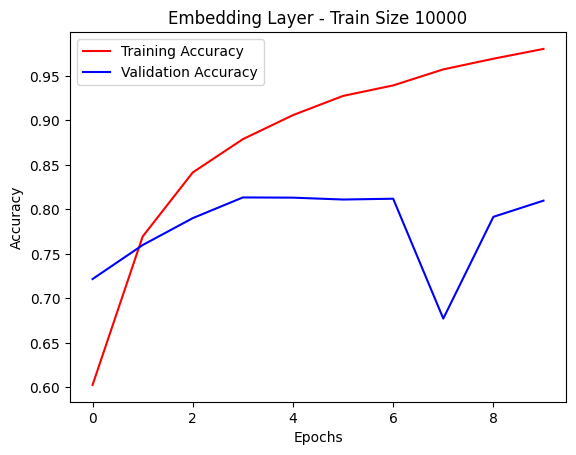

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.5504 - loss: 0.6914 - val_accuracy: 0.5436 - val_loss: 0.7143
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.6340 - loss: 0.6489 - val_accuracy: 0.6875 - val_loss: 0.5940
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.7029 - loss: 0.5835 - val_accuracy: 0.7112 - val_loss: 0.5617
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - accuracy: 0.7280 - loss: 0.5498 - val_accuracy: 0.6244 - val_loss: 0.7136
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.7565 - loss: 0.5066 - val_accuracy: 0.7574 - val_loss: 0.5121
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.7765 - loss: 0.4733 - val_accuracy: 0.7682 - val_loss: 0.4847
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.7841 - loss: 0.4475 - val_accuracy: 0.7351 - val_loss: 0.5425
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.8020 - loss: 0.4259 - val_

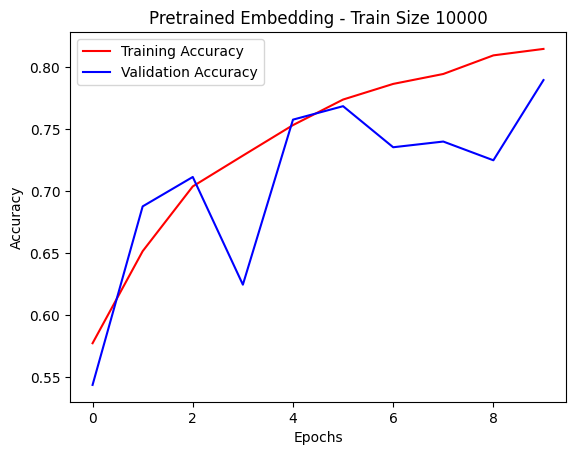

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8025 - loss: 0.4705
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8098 - loss: 0.4541
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7879 - loss: 0.4517
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7871 - loss: 0.4504
{'train_size': 100, 'model': 'Embedding Layer', 'train_acc': 0.9768750071525574, 'val_acc': 0.7900500297546387, 'test_acc': 0.7787600159645081, 'train_loss': 0.06957553327083588, 'val_loss': 0.45687827467918396, 'test_loss': 0.46595320105552673}
{'train_size': 100, 'model': 'Pretrained Embedding', 'train_acc': 0.7909374833106995, 'val_acc': 0.7851999998092651, 'test_acc': 0.7805600166320801, 'train_loss': 0.44628044962882996, 'val_loss': 0.4581722021102905, 'test_loss': 0.46631598472595215}
{'train_size': 1000, 'model': 'Embedding Layer', 'train_acc': 0.9702000021934509, 'val_acc': 0.8096500039100647, 'test_acc': 0.7981600165367126, 'train_loss': 0.10288064926862717, 'val_loss': 0.426298

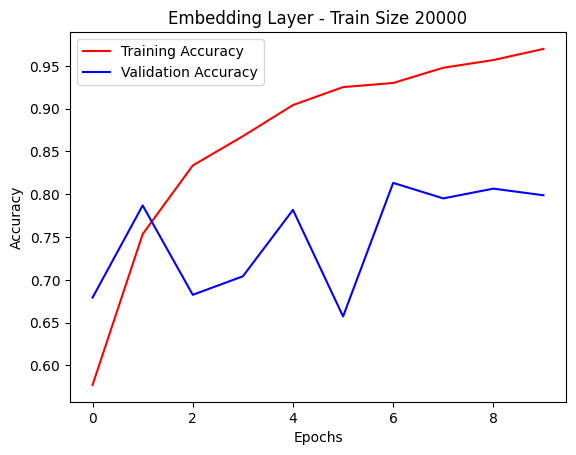

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.5316 - loss: 0.6924 - val_accuracy: 0.5422 - val_loss: 0.7531
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.6554 - loss: 0.6306 - val_accuracy: 0.7127 - val_loss: 0.5704
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.7051 - loss: 0.5832 - val_accuracy: 0.7113 - val_loss: 0.5728
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.7298 - loss: 0.5449 - val_accuracy: 0.5807 - val_loss: 0.8762
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.7492 - loss: 0.5301 - val_accuracy: 0.6697 - val_loss: 0.6487
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 55ms/step - accuracy: 0.7748 - loss: 0.4908 - val_accuracy: 0.6865 - val_loss: 0.6371
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.7813 - loss: 0.4640 - val_accuracy: 0.7840 - val_loss: 0.4636
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.7960 - loss: 0.4382 - val_a

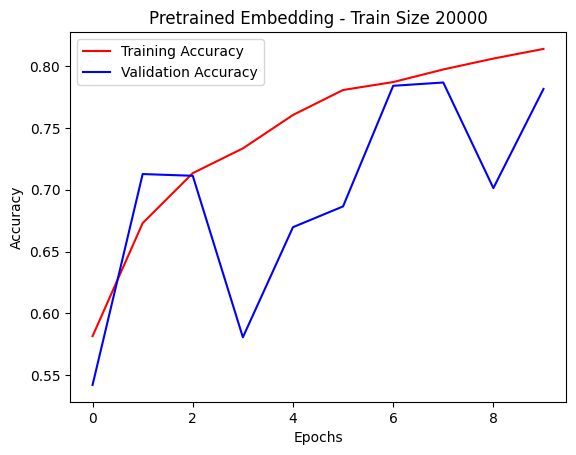

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7734 - loss: 0.4729
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7807 - loss: 0.4616
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7874 - loss: 0.4587
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7843 - loss: 0.4607
{'train_size': 100, 'model': 'Embedding Layer', 'train_acc': 0.9768750071525574, 'val_acc': 0.7900500297546387, 'test_acc': 0.7787600159645081, 'train_loss': 0.06957553327083588, 'val_loss': 0.45687827467918396, 'test_loss': 0.46595320105552673}
{'train_size': 100, 'model': 'Pretrained Embedding', 'train_acc': 0.7909374833106995, 'val_acc': 0.7851999998092651, 'test_acc': 0.7805600166320801, 'train_loss': 0.44628044962882996, 'val_loss': 0.4581722021102905, 'test_loss': 0.46631598472595215}
{'train_size': 1000, 'model': 'Embedding Layer', 'train_acc': 0.9702000021934509, 'val_acc': 0.8096500039100647, 'test_acc': 0.7981600165367126, 'train_loss': 0.10288064926862717, 'val_loss': 0.426298

In [129]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Initialize the results list to store metrics
results = []

# -----------------------------
# Loop over training sample sizes
# -----------------------------

train_sample_sizes = [100, 1000, 3000, 5000, 10000, 20000]
for train_size in train_sample_sizes:
    print(f"Training with {train_size} samples...")

    # Load training dataset with the specific sample size
    train_ds = keras.utils.text_dataset_from_directory(
        "aclImdb/train", batch_size= batch_size
    ).take(train_size)

    # Map datasets for vectorization
    int_train_ds = train_ds.map(
        lambda x, y: (t_vectorization(x), y),
        num_parallel_calls=4
    )
    int_val_ds = v_ds.map(
        lambda x, y: (t_vectorization(x), y),
        num_parallel_calls=4
    )
    int_test_ds = te_ds.map(
        lambda x, y: (t_vectorization(x), y),
        num_parallel_calls=4
    )

    # -----------------------------
    # 1. RNN with trainable embedding layer
    # -----------------------------
    embedding_layer = layers.Embedding(input_dim=train_sample,
        output_dim=embd_dim, input_length=max_length)

    inputs = keras.Input(shape=(max_length,), dtype="int32")
    x = embedding_layer(inputs)
    x = layers.Bidirectional(layers.LSTM(32))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

    callbacks = [
        keras.callbacks.ModelCheckpoint(f"embedding_layer_model_{train_size}.weights.h5", save_best_only=True, save_weights_only=True)
    ]

    history = model.fit(int_train_ds, validation_data=int_val_ds, epochs=10, callbacks=callbacks)

    # Load best weights
    model.load_weights(f"embedding_layer_model_{train_size}.weights.h5")

    # Evaluate
    train_acc = history.history['accuracy'][-1]
    val_acc = model.evaluate(int_val_ds, verbose=0)[1]
    test_acc = model.evaluate(int_test_ds, verbose=0)[1]

    # Plot training/validation accuracy
    plt.figure()
    plt.plot(history.history['accuracy'], "r", label="Training Accuracy")
    plt.plot(history.history['val_accuracy'], "b", label="Validation Accuracy")
    plt.title(f"Embedding Layer - Train Size {train_size}")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    # -----------------------------
    # 2. RNN with pretrained embeddings
    # -----------------------------
    embedding_layer_pretrained = layers.Embedding(
        input_dim=train_sample,
        output_dim=embd_dim,
        embeddings_initializer=keras.initializers.Constant(embd_matrix),
        input_length= max_length,
        trainable=False
    )

    inputs = keras.Input(shape=(max_length,), dtype="int32")
    x = embedding_layer_pretrained(inputs)
    x = layers.Bidirectional(layers.LSTM(32))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model_pre = keras.Model(inputs, outputs)
    model_pre.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

    callbacks = [
        keras.callbacks.ModelCheckpoint(f"pretrained_embedding_model_{train_size}.weights.h5", save_best_only=True, save_weights_only=True)
    ]

    history_pre = model_pre.fit(int_train_ds, validation_data=int_val_ds, epochs=10, callbacks=callbacks)

    # Load best weights
    model_pre.load_weights(f"pretrained_embedding_model_{train_size}.weights.h5")

    # Evaluate
    val_acc_pre = model_pre.evaluate(int_val_ds, verbose=0)[1]
    test_acc_pre = model_pre.evaluate(int_test_ds, verbose=0)[1]

    # Plot training/validation accuracy
    plt.figure()
    plt.plot(history_pre.history['accuracy'], "r", label="Training Accuracy")
    plt.plot(history_pre.history['val_accuracy'], "b", label="Validation Accuracy")
    plt.title(f"Pretrained Embedding - Train Size {train_size}")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    # -----------------------------
    # Store results
    # -----------------------------
    # Evaluate embedding layer model
    test_loss, test_acc = model.evaluate(int_test_ds)
    val_loss, val_acc = model.evaluate(int_val_ds)
    train_acc = history.history["accuracy"][-1]
    train_loss = history.history["loss"][-1]

    results.append({
      "train_size": train_size,
      "model": "Embedding Layer",
      "train_acc": train_acc,
      "val_acc": val_acc,
      "test_acc": test_acc,
      "train_loss": train_loss,
      "val_loss": val_loss,
      "test_loss": test_loss
  })

    # Evaluate pretrained embedding model
    test_loss, test_acc = model_pre.evaluate(int_test_ds)
    val_loss, val_acc = model_pre.evaluate(int_val_ds)
    train_acc = history_pre.history["accuracy"][-1]
    train_loss = history_pre.history["loss"][-1]

    results.append({
      "train_size": train_size,
      "model": "Pretrained Embedding",
      "train_acc": train_acc,
      "val_acc": val_acc,
      "test_acc": test_acc,
      "train_loss": train_loss,
      "val_loss": val_loss,
      "test_loss": test_loss
  })

    # -----------------------------
    # Print summary
    # -----------------------------
    for r in results:
      print(r)
